In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Carregar série já processada
df_series = pd.read_parquet('/home/valentim/divea/data/processed/series_semanais.parquet')

print(f"Shape: {df_series.shape}")
print(df_series.head())

Shape: (382, 4)
            casos  influenza  covid  vsr
DT_NOTIFIC                              
2018-12-31     13        1.0    0.0  1.0
2019-01-07     39        1.0    0.0  1.0
2019-01-14     51        2.0    0.0  5.0
2019-01-21     29        1.0    0.0  4.0
2019-01-28     45        1.0    0.0  0.0


In [3]:
# Série de Influenza
serie = df_series['influenza'].values.reshape(-1, 1)

print(f"Total de semanas: {len(serie)}")
print(f"Média: {serie.mean():.1f}")
print(f"Máximo: {serie.max():.1f}")
print(f"Semanas com zero casos: {(serie == 0).sum()}")

Total de semanas: 382
Média: 25.5
Máximo: 370.0
Semanas com zero casos: 92


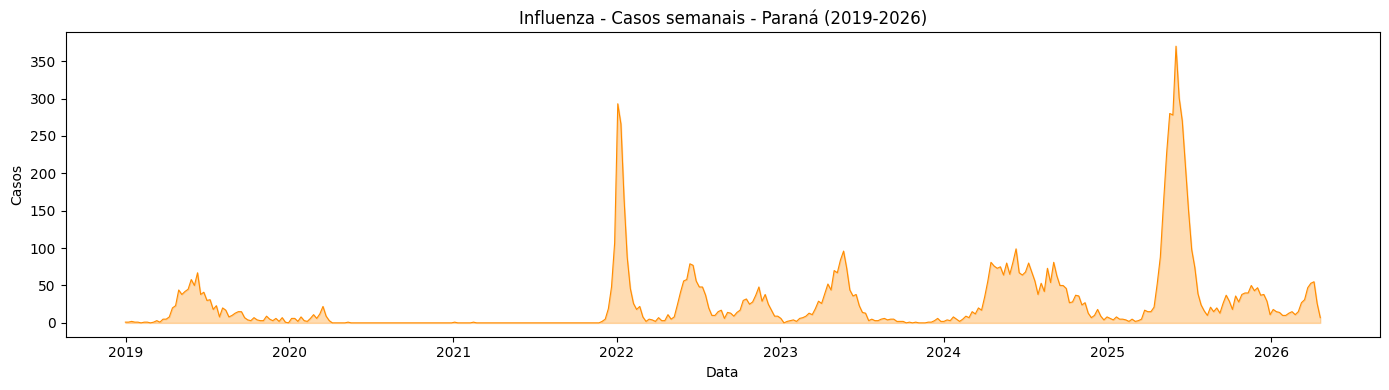

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_series.index, df_series['influenza'], color='darkorange', linewidth=0.8)
ax.fill_between(df_series.index, df_series['influenza'], alpha=0.3, color='darkorange')
ax.set_title('Influenza - Casos semanais - Paraná (2019-2026)')
ax.set_xlabel('Data')
ax.set_ylabel('Casos')
plt.tight_layout()
plt.savefig('/home/valentim/divea/outputs/serie_influenza.png', dpi=150)
plt.show()

In [5]:
# Excluir período pandêmico 2020-2021
df_flu = df_series['influenza'].copy()
df_flu = df_flu[(df_flu.index < '2020-01-01') | (df_flu.index >= '2022-01-01')]

print(f"Semanas após exclusão: {len(df_flu)}")
print(f"Semanas com zero: {(df_flu == 0).sum()}")
print(f"Período: {df_flu.index.min()} a {df_flu.index.max()}")

Semanas após exclusão: 278
Semanas com zero: 9
Período: 2018-12-31 00:00:00 a 2026-04-20 00:00:00


In [6]:
# Preparar janelas temporais - Influenza
JANELA = 12
HORIZONTE = 4

scaler_flu = MinMaxScaler()
serie_norm = scaler_flu.fit_transform(serie.reshape(-1, 1))

X, y = [], []
for i in range(len(serie_norm) - JANELA - HORIZONTE):
    X.append(serie_norm[i:i+JANELA])
    y.append(serie_norm[i+JANELA:i+JANELA+HORIZONTE].flatten())

X = np.array(X)
y = np.array(y)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")

Treino: 292 | Teste: 74


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.FloatTensor(y_test).to(device)

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=4):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

model_flu = LSTMModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_flu.parameters(), lr=0.001)

EPOCHS = 200
for epoch in range(EPOCHS):
    model_flu.train()
    optimizer.zero_grad()
    output = model_flu(X_train_t)
    loss = criterion(output, y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {loss.item():.6f}")

print("\nTreinamento concluído.")

Epoch 20/200 - Loss: 0.008206
Epoch 40/200 - Loss: 0.008032
Epoch 60/200 - Loss: 0.007413
Epoch 80/200 - Loss: 0.006885
Epoch 100/200 - Loss: 0.006262
Epoch 120/200 - Loss: 0.005483
Epoch 140/200 - Loss: 0.004991
Epoch 160/200 - Loss: 0.004337
Epoch 180/200 - Loss: 0.003986
Epoch 200/200 - Loss: 0.003489

Treinamento concluído.


In [8]:
model_flu.eval()
with torch.no_grad():
    pred = model_flu(X_test_t).cpu().numpy()
    real = y_test_t.cpu().numpy()

pred_orig = scaler_flu.inverse_transform(pred)
real_orig = scaler_flu.inverse_transform(real)

for semana in range(4):
    mae = mean_absolute_error(real_orig[:, semana], pred_orig[:, semana])
    rmse = np.sqrt(mean_squared_error(real_orig[:, semana], pred_orig[:, semana]))
    print(f"Semana +{semana+1} — MAE: {mae:.1f} casos | RMSE: {rmse:.1f} casos")

print(f"\nMédia semanal no teste: {real_orig.mean():.1f}")

Semana +1 — MAE: 22.0 casos | RMSE: 49.7 casos
Semana +2 — MAE: 28.0 casos | RMSE: 61.8 casos
Semana +3 — MAE: 30.4 casos | RMSE: 66.0 casos
Semana +4 — MAE: 34.5 casos | RMSE: 72.1 casos

Média semanal no teste: 51.2


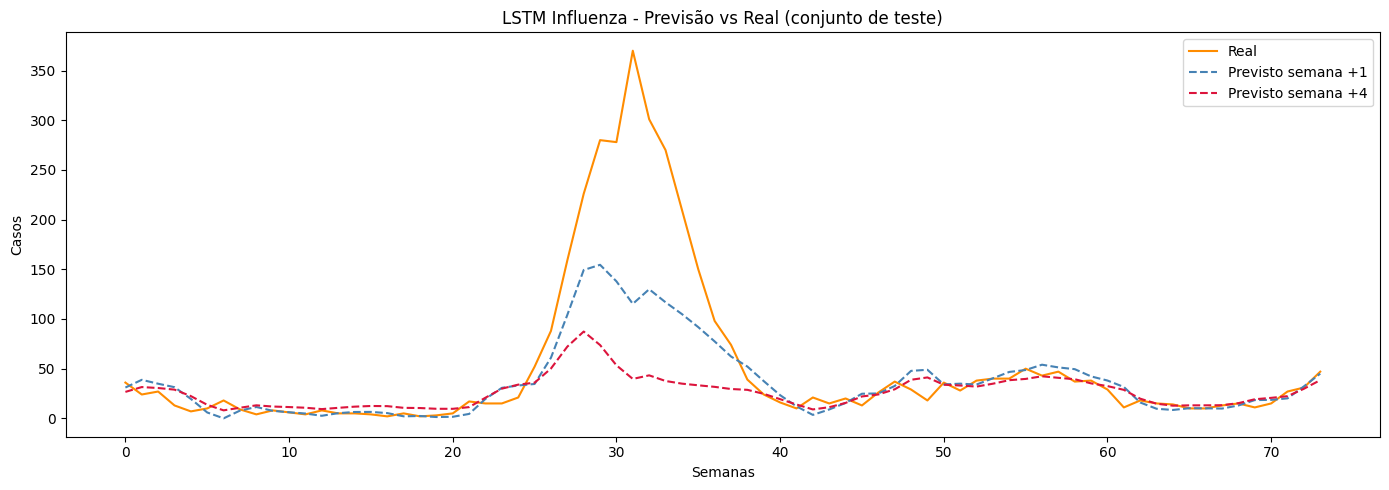

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(real_orig[:, 0], label='Real', color='darkorange', linewidth=1.5)
ax.plot(pred_orig[:, 0], label='Previsto semana +1',
        color='steelblue', linewidth=1.5, linestyle='--')
ax.plot(pred_orig[:, 3], label='Previsto semana +4',
        color='crimson', linewidth=1.5, linestyle='--')

ax.set_title('LSTM Influenza - Previsão vs Real (conjunto de teste)')
ax.set_xlabel('Semanas')
ax.set_ylabel('Casos')
ax.legend()
plt.tight_layout()
plt.savefig('/home/valentim/divea/outputs/lstm_influenza.png', dpi=150)
plt.show()

In [10]:
torch.save({
    'model_state': model_flu.state_dict(),
    'scaler': scaler_flu,
    'janela': JANELA,
    'horizonte': HORIZONTE
}, '/home/valentim/divea/models/lstm_influenza.pt')

print("Modelo salvo.")

Modelo salvo.


In [11]:
# Série VSR — sem exclusão de período (VSR não foi suprimido tanto quanto Influenza)
serie_vsr = df_series['vsr'].values

print(f"Total semanas: {len(serie_vsr)}")
print(f"Média: {serie_vsr.mean():.1f}")
print(f"Máximo: {serie_vsr.max():.1f}")
print(f"Semanas com zero: {(serie_vsr == 0).sum()}")

Total semanas: 382
Média: 39.5
Máximo: 340.0
Semanas com zero: 40


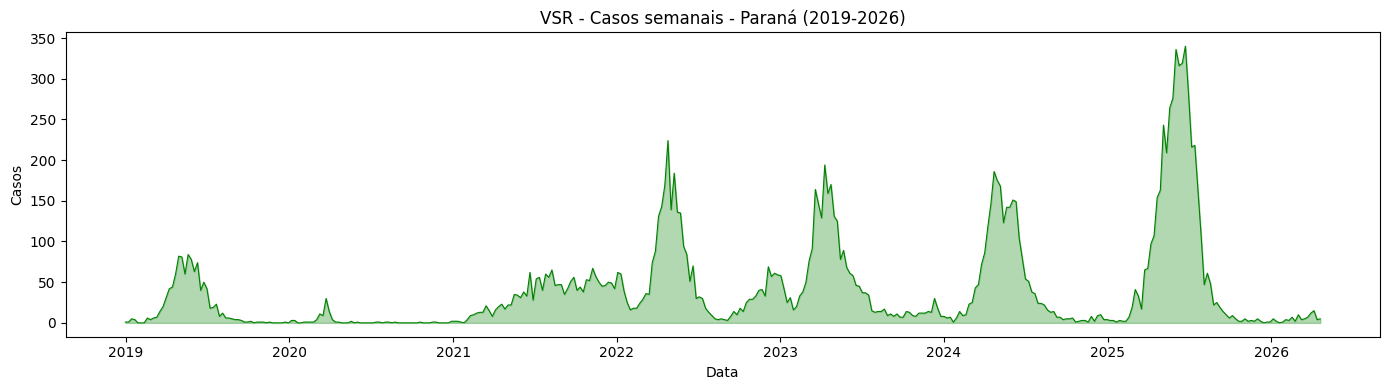

In [12]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_series.index, df_series['vsr'], color='green', linewidth=0.8)
ax.fill_between(df_series.index, df_series['vsr'], alpha=0.3, color='green')
ax.set_title('VSR - Casos semanais - Paraná (2019-2026)')
ax.set_xlabel('Data')
ax.set_ylabel('Casos')
plt.tight_layout()
plt.show()

In [13]:
serie_vsr = df_series['vsr'].values.reshape(-1, 1)

scaler_vsr = MinMaxScaler()
serie_norm = scaler_vsr.fit_transform(serie_vsr)

X, y = [], []
for i in range(len(serie_norm) - JANELA - HORIZONTE):
    X.append(serie_norm[i:i+JANELA])
    y.append(serie_norm[i+JANELA:i+JANELA+HORIZONTE].flatten())

X = np.array(X)
y = np.array(y)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")

Treino: 292 | Teste: 74


In [14]:
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.FloatTensor(y_test).to(device)

model_vsr = LSTMModel().to(device)
optimizer = torch.optim.Adam(model_vsr.parameters(), lr=0.001)

for epoch in range(EPOCHS):
    model_vsr.train()
    optimizer.zero_grad()
    output = model_vsr(X_train_t)
    loss = criterion(output, y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {loss.item():.6f}")

print("\nTreinamento concluído.")

Epoch 20/200 - Loss: 0.016251
Epoch 40/200 - Loss: 0.013303
Epoch 60/200 - Loss: 0.010289
Epoch 80/200 - Loss: 0.006501
Epoch 100/200 - Loss: 0.004938
Epoch 120/200 - Loss: 0.004129
Epoch 140/200 - Loss: 0.003984
Epoch 160/200 - Loss: 0.003345
Epoch 180/200 - Loss: 0.003140
Epoch 200/200 - Loss: 0.003071

Treinamento concluído.


Semana +1 — MAE: 17.9 casos | RMSE: 35.2 casos
Semana +2 — MAE: 22.6 casos | RMSE: 42.2 casos
Semana +3 — MAE: 27.9 casos | RMSE: 51.3 casos
Semana +4 — MAE: 32.8 casos | RMSE: 58.5 casos

Média semanal no teste: 60.5


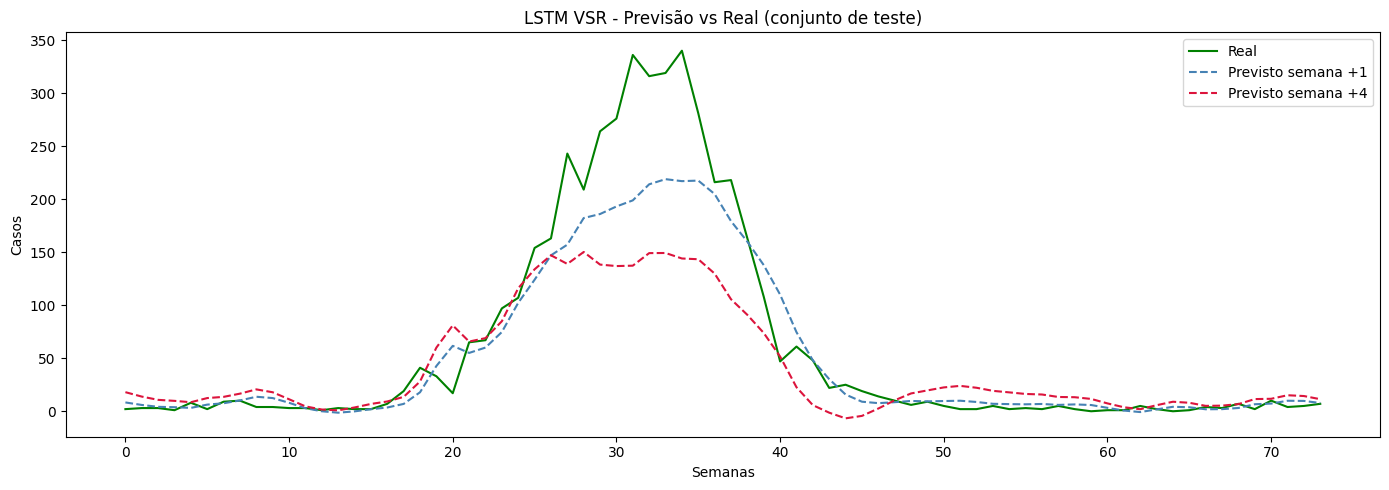

In [15]:
model_vsr.eval()
with torch.no_grad():
    pred = model_vsr(X_test_t).cpu().numpy()
    real = y_test_t.cpu().numpy()

pred_orig = scaler_vsr.inverse_transform(pred)
real_orig = scaler_vsr.inverse_transform(real)

for semana in range(4):
    mae = mean_absolute_error(real_orig[:, semana], pred_orig[:, semana])
    rmse = np.sqrt(mean_squared_error(real_orig[:, semana], pred_orig[:, semana]))
    print(f"Semana +{semana+1} — MAE: {mae:.1f} casos | RMSE: {rmse:.1f} casos")

print(f"\nMédia semanal no teste: {real_orig.mean():.1f}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(real_orig[:, 0], label='Real', color='green', linewidth=1.5)
ax.plot(pred_orig[:, 0], label='Previsto semana +1',
        color='steelblue', linewidth=1.5, linestyle='--')
ax.plot(pred_orig[:, 3], label='Previsto semana +4',
        color='crimson', linewidth=1.5, linestyle='--')
ax.set_title('LSTM VSR - Previsão vs Real (conjunto de teste)')
ax.set_xlabel('Semanas')
ax.set_ylabel('Casos')
ax.legend()
plt.tight_layout()
plt.savefig('/home/valentim/divea/outputs/lstm_vsr.png', dpi=150)
plt.show()

In [16]:
torch.save({
    'model_state': model_vsr.state_dict(),
    'scaler': scaler_vsr,
    'janela': JANELA,
    'horizonte': HORIZONTE
}, '/home/valentim/divea/models/lstm_vsr.pt')

print("Modelo salvo.")

Modelo salvo.
